# Model Training & Experimentation Notebook

A working scaffold derived from **`ML_Model_Building_Template.md`**, wired to **`new_dataset.csv`** (210,577 ACS PUMS rows). Run top-to-bottom. Classification / deep-learning branches are kept commented where they differ.

**Dataset:** `new_dataset.csv` — socio-economic features from the ACS PUMS Income dataset.

| Column | Meaning |
|---|---|
| `AGEP` | Age in years |
| `COW` | Class of worker (employment sector) |
| `SCHL` | Education level (ordinal code) |
| `WKHP` | Usual hours worked per week |
| `SEX` | Sex |
| `OCCP` | Occupation group code |
| `MAR` | Marital status |
| `RELP` | Household role |
| `RAC1P` | Race group |
| **`PINCP`** | **Target — annual personal income (USD)** |

| Stage | Name | Key concern |
|---|---|---|
| 1 | Environment Setup | Reproducibility |
| 2 | Data Loading & Preview | Understand structure & quality |
| 3 | Data Cleaning | Missing values → encoding → imbalance |
| 4 | Graphical EDA | Distributions & relationships |
| 5 | Feature Engineering | Identify → generate → select |
| 6 | Train / Val / Test Split | Stratified, no leakage |
| 7 | Feature Scaling | Fit on train only |
| 8 | Model Architecture | Algorithm choice & hyperparameters |
| 9 | Training | Cross-validation or epoch-based |
| 10 | Learning Curves | Diagnose over/underfitting (DL) |
| 11 | Evaluation | Training + test metrics |
| 12 | Save & Inference | Persistence & deployment |

> **Task type:** **regression** — predict `PINCP` from the remaining features. Classification branches are commented where noted.

## Stage 1 — Environment Setup & Library Imports

Import everything upfront, set display options so nothing is truncated, and fix a global seed for reproducibility.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display options
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
np.set_printoptions(threshold=10000)

## Stage 2 — Data Loading & Textual Preview

Load `new_dataset.csv` and inspect it textually: shape, head/tail, schema, summary stats, and target distribution. Note any data-quality problems to fix in Stage 3.

In [2]:
# Load dataset
dataset = pd.read_csv("new_dataset.csv", header=0, index_col=None)

TARGET_COLUMN   = "PINCP"
FEATURE_COLUMNS = [c for c in dataset.columns if c != TARGET_COLUMN]
# Continuous vs. categorical (categoricals are integer-coded ACS values)
CONTINUOUS_COLS  = ["AGEP", "WKHP"]
CATEGORICAL_COLS = ["SEX", "RELP", "RAC1P", "MAR", "COW", "SCHL", "OCCP"]

print("Shape:", dataset.shape, "\n")
print(dataset.head(), "\n")
print(dataset.tail(), "\n")

Shape: (210577, 10) 

   SEX  RELP  RAC1P  MAR  COW  SCHL    PINCP  WKHP    OCCP  AGEP
0  1.0   0.0    1.0  5.0  1.0  20.0  44220.0  40.0  2805.0  42.0
1  1.0   0.0    1.0  1.0  6.0  16.0  32702.0  32.0   440.0  62.0
2  2.0   1.0    1.0  1.0  4.0  21.0  50050.0  40.0  2014.0  64.0
3  1.0   0.0    1.0  1.0  1.0  19.0  40001.0  48.0  4710.0  26.0
4  2.0   1.0    3.0  1.0  1.0  19.0  20000.0  40.0  2014.0  24.0 

        SEX  RELP  RAC1P  MAR  COW  SCHL    PINCP  WKHP    OCCP  AGEP
210572  2.0   0.0    6.0  5.0  1.0  19.0  25110.0  10.0  4720.0  35.0
210573  1.0   6.0    6.0  1.0  1.0   8.0  92040.0  40.0  6260.0  85.0
210574  2.0   6.0    6.0  1.0  1.0   8.0  13000.0  30.0  4230.0  85.0
210575  1.0   0.0    1.0  1.0  1.0  20.0  80225.0  40.0  4810.0  46.0
210576  2.0   1.0    9.0  1.0  5.0  21.0  50601.0  40.0  4530.0  45.0 



<class 'pandas.DataFrame'>
RangeIndex: 210577 entries, 0 to 210576
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   SEX     210577 non-null  float64
 1   RELP    210577 non-null  float64
 2   RAC1P   210577 non-null  float64
 3   MAR     210577 non-null  float64
 4   COW     210577 non-null  float64
 5   SCHL    210577 non-null  float64
 6   PINCP   210577 non-null  float64
 7   WKHP    210577 non-null  float64
 8   OCCP    210577 non-null  float64
 9   AGEP    210577 non-null  float64
dtypes: float64(10)
memory usage: 16.1 MB
None 

                 SEX           RELP          RAC1P            MAR            COW           SCHL         PINCP           WKHP           OCCP           AGEP
count  210577.000000  210577.000000  210577.000000  210577.000000  210577.000000  210577.000000  2.105770e+05  210577.000000  210577.000000  210577.000000
mean        1.474154       1.735607       1.727786       2.492532       1.970785     

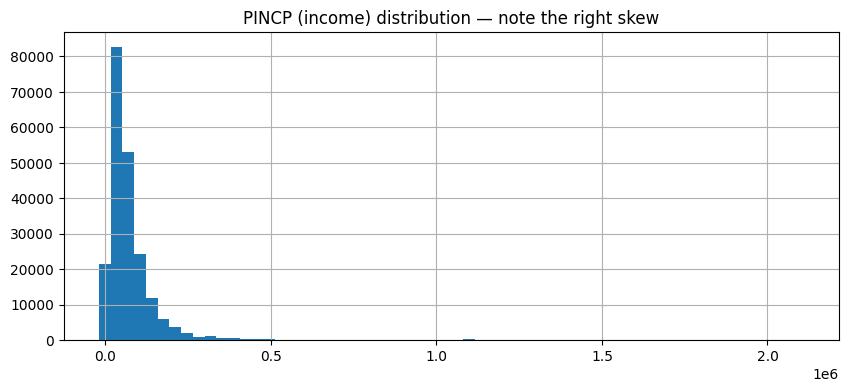

In [3]:
# Structure, dtypes, missing counts, summary stats
print(dataset.info(), "\n")
print(dataset.describe(), "\n")
print("Missing values per column:\n", dataset.isna().sum(), "\n")

# Target distribution (regression -> describe + histogram)
print(dataset[TARGET_COLUMN].describe())
dataset[TARGET_COLUMN].hist(bins=60, figsize=(10, 4))
plt.title("PINCP (income) distribution — note the right skew"); plt.show()

## Stage 3 — Data Cleaning & Problem Fixing

Fix data-quality problems **before** encoding/transformation, in the order **missing values → categorical encoding → class imbalance**. `new_dataset.csv` is already integer-coded and has no missing values, so most of this is a guard/no-op — kept here for the template workflow.

In [5]:
# 3a — Missing values (KNN imputation). new_dataset.csv has none, so this is a guard.
from sklearn.impute import KNNImputer

cols_with_nulls = [c for c in dataset.columns if dataset[c].isna().any()]
if cols_with_nulls:
    knn_imputer = KNNImputer(n_neighbors=5)
    dataset[cols_with_nulls] = knn_imputer.fit_transform(dataset[cols_with_nulls])

print("Remaining missing values:", int(dataset.isna().sum().sum()))

Remaining missing values: 0


In [6]:
# 3b — Categorical / text encoding.
# new_dataset.csv categoricals are ALREADY integer-coded (ACS codes), so no encoding
# is required. If you instead start from raw string categories, use OrdinalEncoder
# (ordered) or pd.get_dummies (nominal). Example:
#
# from sklearn.preprocessing import OrdinalEncoder
# encoder = OrdinalEncoder(categories=[["Less than HS", "HS/GED", "Some College",
#                                       "Associate's", "Bachelor's", "Graduate+"]])
# dataset["SCHL"] = encoder.fit_transform(dataset[["SCHL"]])

In [7]:
# 3c — Class imbalance (CLASSIFICATION ONLY — not applicable to this regression target).
# from imblearn.over_sampling import SVMSMOTE
# svm_smote = SVMSMOTE(sampling_strategy='not majority', k_neighbors=5)
# resampled_X, resampled_y = svm_smote.fit_resample(feats_X, trgt_y)

## Stage 4 — Graphical Data Exploration (EDA)

Visualise distributions and relationships before engineering features. The skewed `PINCP`/`AGEP`/`WKHP` histograms below justify the scaling in Stage 7.

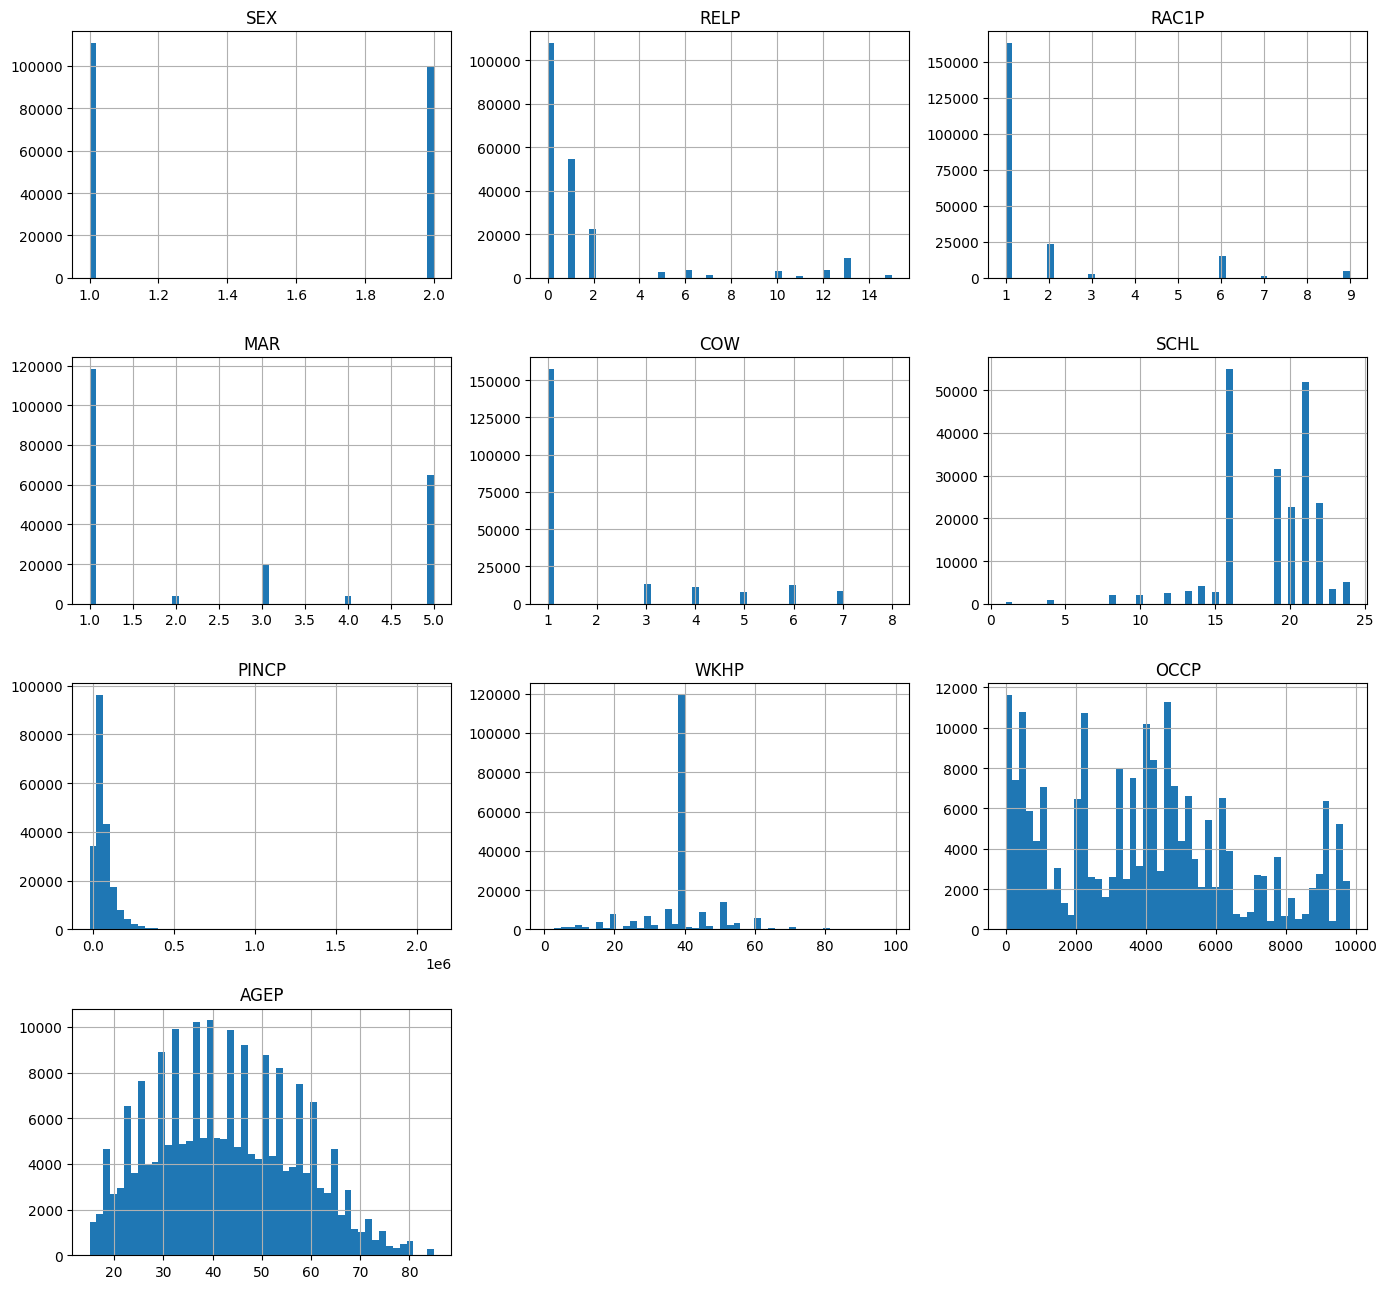

In [8]:
# Distribution of every column
dataset.hist(bins=50, figsize=(14, 13))
plt.tight_layout()
plt.show()

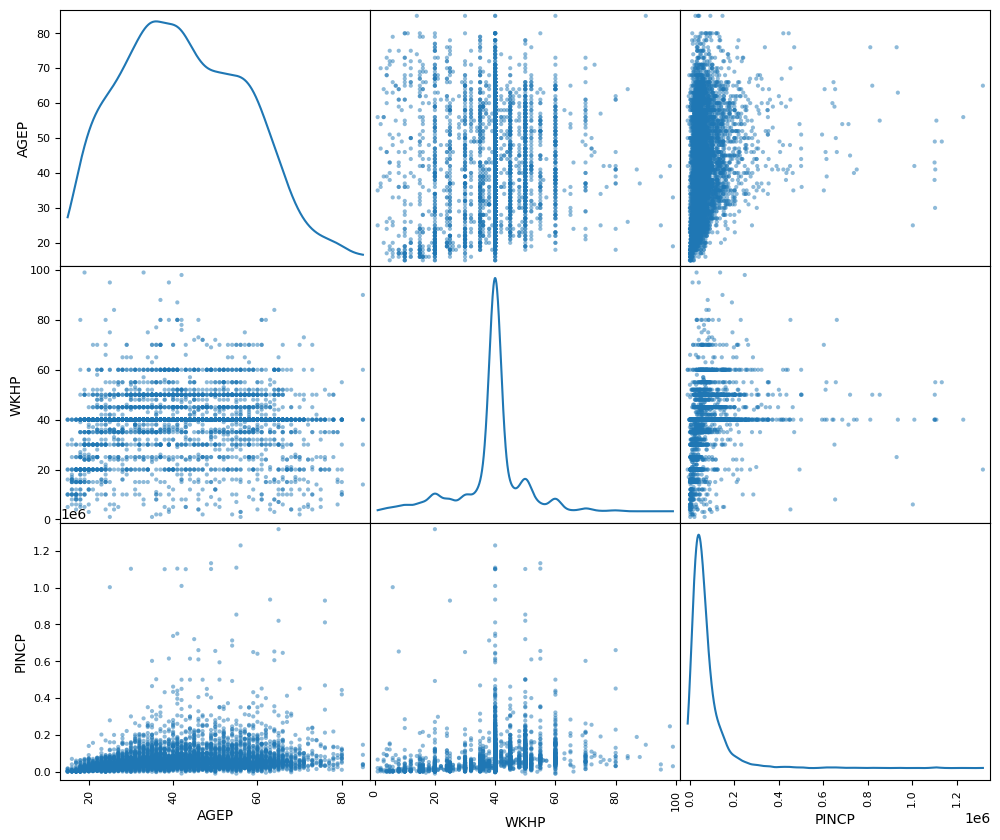

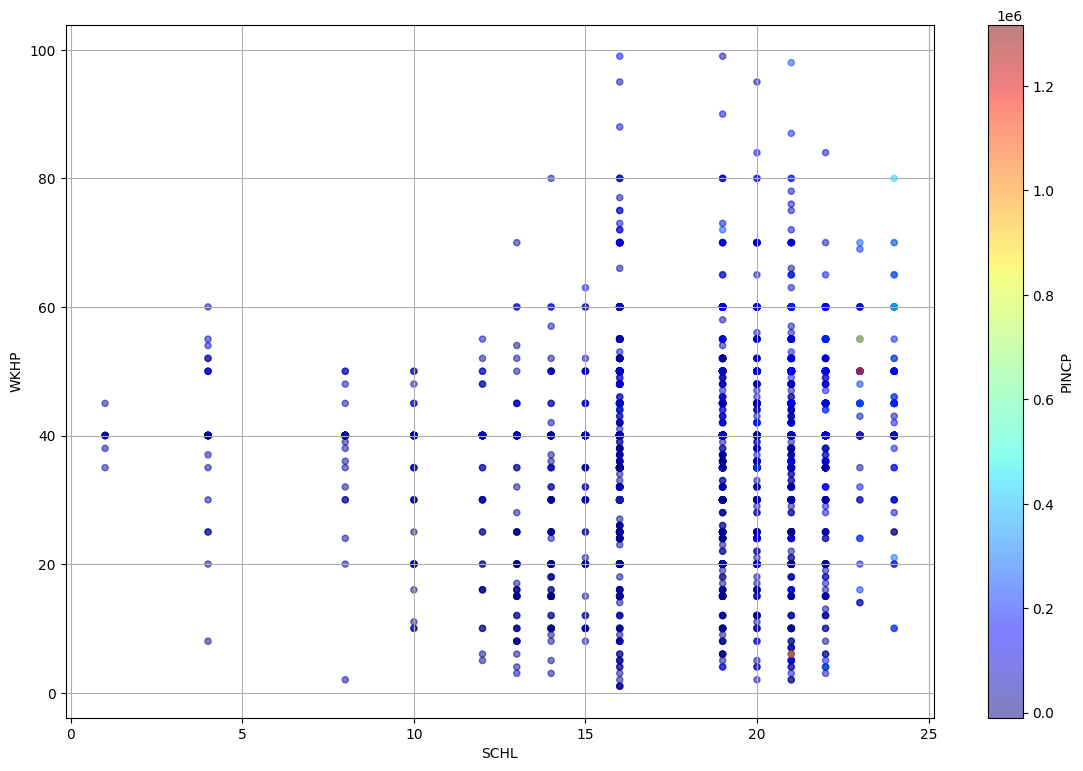

In [9]:
# Pairwise scatter matrix on the continuous features + target
from pandas.plotting import scatter_matrix

attributes = CONTINUOUS_COLS + [TARGET_COLUMN]
scatter_matrix(dataset[attributes].sample(5000, random_state=RANDOM_STATE),
               alpha=0.5, figsize=(12, 10), diagonal='kde')
plt.show()

# Focused scatter: education vs. hours worked, coloured by income
dataset.sample(5000, random_state=RANDOM_STATE).plot(
    kind="scatter", x="SCHL", y="WKHP", c=TARGET_COLUMN, cmap="jet",
    colorbar=True, grid=True, figsize=(14, 9), alpha=0.5)
plt.show()

## Stage 5 — Feature Engineering

**Identify** features vs. target → **generate** more expressive features → **select** the non-redundant subset that correlates with the target.

In [10]:
# 5a — Feature identification
feats_X = dataset.loc[:, FEATURE_COLUMNS].copy()
trgt_y  = pd.DataFrame(dataset.loc[:, [TARGET_COLUMN]])
print("feats_X:", feats_X.shape, "| trgt_y:", trgt_y.shape)

feats_X: (210577, 9) | trgt_y: (210577, 1)


In [11]:
# 5b — Feature generation (interaction terms that may better explain income)
feats_X["WKHPxSCHL"] = feats_X["WKHP"] * feats_X["SCHL"]   # effort x education
feats_X["AGEPxSCHL"] = feats_X["AGEP"] * feats_X["SCHL"]   # experience x education

# Sanity check for inf / NaN introduced by feature math
indices = np.where(np.isinf(feats_X.values) | np.isnan(feats_X.values))
print("'NaN' or 'inf' indices:", list(zip(*indices)))

'NaN' or 'inf' indices: []


Selected features: ['RELP', 'MAR', 'SCHL', 'WKHP', 'OCCP', 'AGEP', 'WKHPxSCHL', 'AGEPxSCHL']


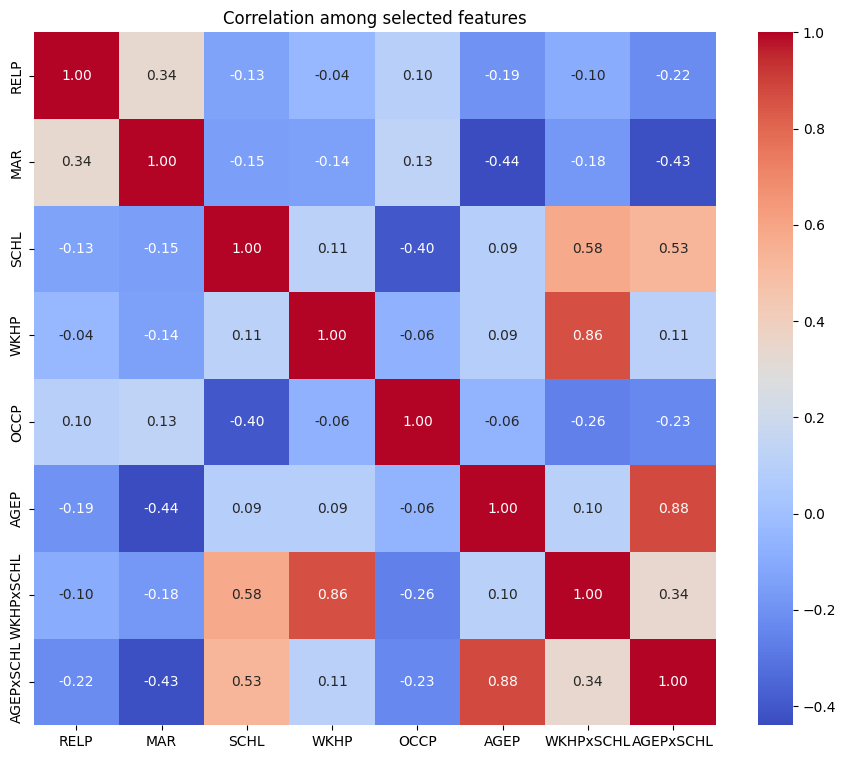

In [12]:
# 5c — Feature selection (regression -> f_regression / mutual_info_regression)
from sklearn.feature_selection import SelectKBest, mutual_info_regression

K = 8
KBest = SelectKBest(score_func=mutual_info_regression, k=K)
KBest.fit(feats_X, trgt_y.iloc[:, 0])
selected = list(KBest.get_feature_names_out())
print("Selected features:", selected)
top_feats_X = feats_X[selected]

# Check multi-collinearity among selected features
plt.figure(figsize=(11, 9))
sbn.heatmap(top_feats_X.corr('pearson'), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation among selected features"); plt.show()

# Finalise the non-redundant feature set (drop collinear pairs as needed)
useful_feats_X = top_feats_X.copy()

## Stage 6 — Train / Validation / Test Split

Regression uses a plain `train_test_split`. A validation set is carved out of train for the optional deep-learning path.

In [13]:
from sklearn.model_selection import train_test_split

X = useful_feats_X
y = trgt_y

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
)

# Optional validation split (deep learning)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  "| y_test: ", y_test.shape)

X_train: (134768, 8) | y_train: (134768, 1)
X_val:   (33693, 8) | y_val:   (33693, 1)
X_test:  (42116, 8) | y_test:  (42116, 1)


## Stage 7 — Feature Scaling / Normalisation

Fit the scaler **only on training data** to avoid leakage, then transform val/test. The target is scaled so predictions can be inverse-transformed before metrics.

> Project Echo's production model instead trains on `log1p(PINCP)`. Pick **one** target transform — the `StandardScaler` below *or* a log transform — not both.

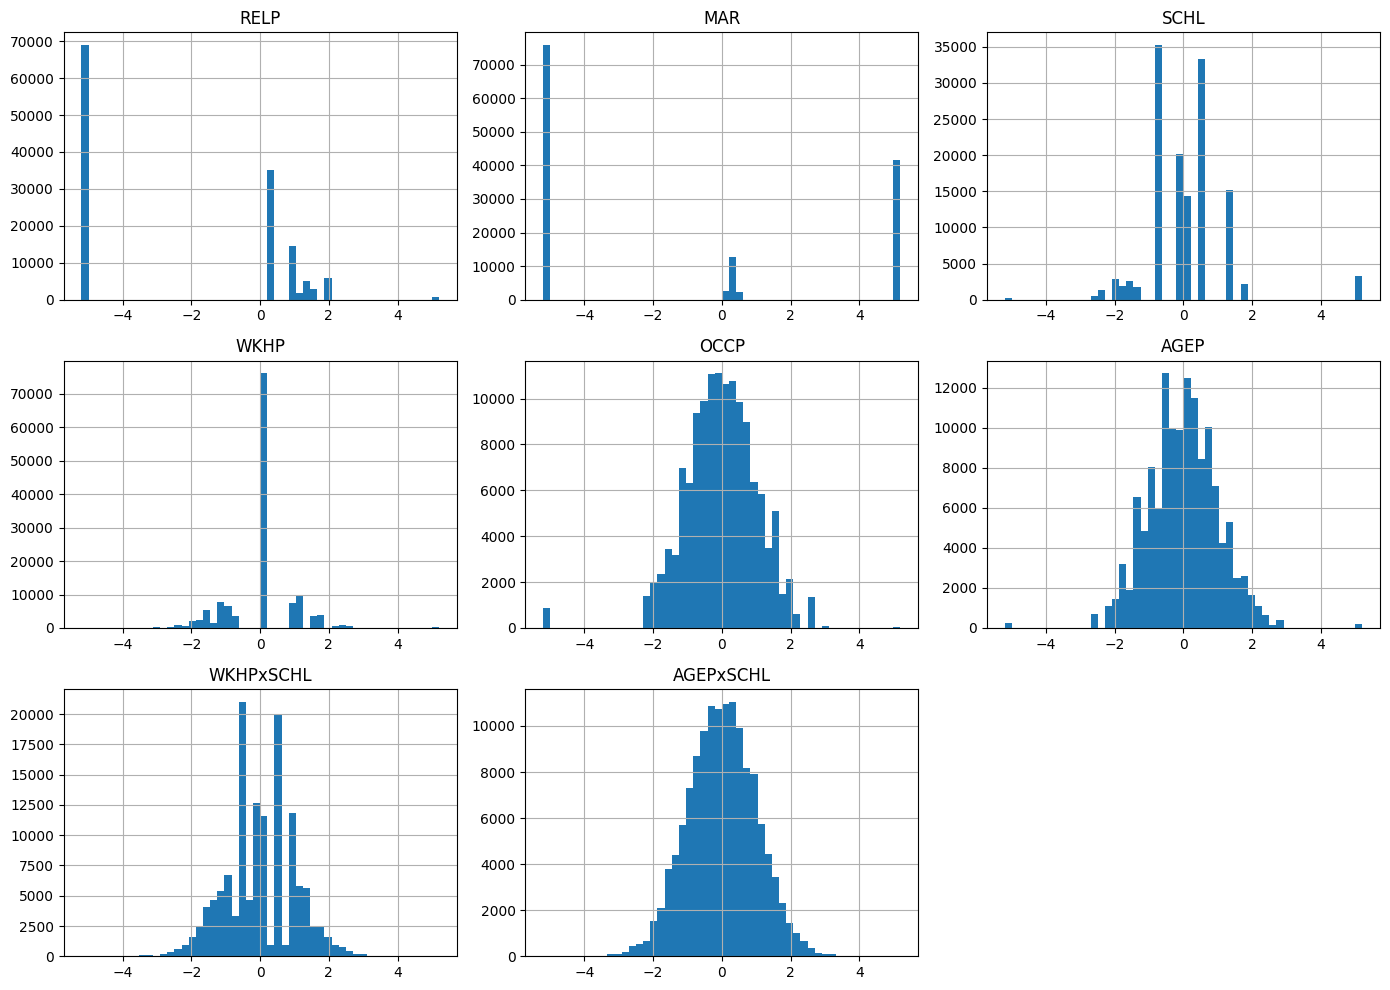

In [14]:
from sklearn.preprocessing import QuantileTransformer, StandardScaler

# --- Features (X) ---
scaler_X = QuantileTransformer(output_distribution='normal', random_state=RANDOM_STATE)
scaler_X.fit(X_train)                 # fit on TRAIN only
X_train_sc = scaler_X.transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

# --- Target (y) ---
scaler_y = StandardScaler()
scaler_y.fit(y_train)
y_train_sc = scaler_y.transform(y_train)
y_val_sc   = scaler_y.transform(y_val)
y_test_sc  = scaler_y.transform(y_test)

# Confirm skew is resolved
pd.DataFrame(X_train_sc, columns=X_train.columns).hist(bins=50, figsize=(14, 10))
plt.tight_layout(); plt.show()

## Stage 8 — Model Selection, Architecture & Compilation

Tabular regression → gradient boosting. Use the traditional-ML cell; the deep-learning cell is optional.

In [15]:
# --- Traditional ML (scikit-learn / gradient boosting) ---
from sklearn.ensemble import RandomForestRegressor
# from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor
# from catboost import CatBoostRegressor

algorithm = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
# Project Echo's production model averages XGBRegressor + LGBMRegressor + CatBoostRegressor.
# To reproduce: train each here and average their predictions in Stage 9 / 11.

In [16]:
# --- Deep Learning (Keras / TensorFlow) — optional ---
# from tensorflow.keras import Sequential, optimizers, losses, metrics
# from tensorflow.keras.layers import Dense, Input
#
# model = Sequential([
#     Input(shape=(X_train_sc.shape[1],)),
#     Dense(128, activation='relu'),
#     Dense(64, activation='relu'),
#     Dense(1, activation='linear'),
# ])
# model.compile(optimizer=optimizers.Adam(1e-3),
#               loss=losses.MeanSquaredError(),
#               metrics=[metrics.MeanAbsoluteError()])
# model.summary()

## Stage 9 — Training

Traditional ML: fit + 3-fold cross-validated predictions. Deep learning: epoch-based `fit` with callbacks.

In [17]:
# --- Traditional ML ---
from sklearn.model_selection import cross_val_predict

algorithm.fit(X_train_sc, y_train_sc.ravel())
cv_preds = cross_val_predict(algorithm, X_train_sc, y_train_sc.ravel(), cv=3)

In [18]:
# --- Deep Learning — optional ---
# from keras.callbacks import EarlyStopping, ReduceLROnPlateau
# callbacks = [
#     EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
#     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
# ]
# history = model.fit(X_train_sc, y_train_sc, batch_size=64, epochs=100, verbose=1,
#                     callbacks=callbacks, validation_data=(X_val_sc, y_val_sc))

## Stage 10 — Learning Curve Visualisation (Deep Learning only)

Large train–validation gap = overfitting; curves that never converge = underfitting. Skip for traditional ML.

In [19]:
# plt.figure(figsize=(15, 6))
# plt.subplot(1, 2, 1); plt.grid()
# plt.plot(history.history['mean_absolute_error'],     'k-',  marker='o', label='Train')
# plt.plot(history.history['val_mean_absolute_error'], 'b--', marker='o', label='Validation')
# plt.xlabel('Epochs'); plt.ylabel('MAE'); plt.legend(loc='best')
#
# plt.subplot(1, 2, 2); plt.grid()
# plt.plot(history.history['loss'],     'k-',  marker='o', label='Train')
# plt.plot(history.history['val_loss'], 'b--', marker='o', label='Validation')
# plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(loc='best')
# plt.show()

## Stage 11 — Evaluation on Training & Test Sets

Report **both** train and test metrics: train ≪ test → overfitting; train ≫ test → underfitting. Invert target scaling before computing regression metrics.

In [20]:
# --- Regression metrics ---
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             explained_variance_score, r2_score)

preds_train_sc = algorithm.predict(X_train_sc).reshape(-1, 1)
preds_test_sc  = algorithm.predict(X_test_sc).reshape(-1, 1)

# Invert target scaling back to dollar scale
preds_train = scaler_y.inverse_transform(preds_train_sc)
preds_test  = scaler_y.inverse_transform(preds_test_sc)

for label, y_true, y_pred in [("Training", y_train.values, preds_train),
                              ("Testing",  y_test.values,  preds_test)]:
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    evs  = explained_variance_score(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{label} Metrics\n{'-'*20}")
    print(f"MAE    : {mae:,.2f}")
    print(f"MSE    : {mse:,.2f}")
    print(f"RMSE   : {rmse:,.2f}")
    print(f"Exp Var: {evs:.4f}")
    print(f"R2     : {r2:.4f}")


Training Metrics
--------------------
MAE    : 18,252.60
MSE    : 1,822,833,457.83
RMSE   : 42,694.65
Exp Var: 0.7882
R2     : 0.7881

Testing Metrics
--------------------
MAE    : 39,530.70
MSE    : 7,167,822,525.77
RMSE   : 84,662.99
Exp Var: 0.1493
R2     : 0.1481


In [21]:
# --- Classification metrics (alternative — not used for this regression target) ---
# from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
#                              matthews_corrcoef, confusion_matrix)
# acc = accuracy_score(y_true, y_pred)
# cm  = confusion_matrix(y_true, y_pred)
# sbn.heatmap(cm, annot=True, fmt='d', cmap='Grays'); plt.show()

## Stage 12 — Model Saving & Inference

Persist the model + both scalers + feature list together so inference reproduces the exact preprocessing (mirrors `income_pipeline.pkl`).

In [22]:
import joblib

bundle = {
    "model": algorithm,
    "scaler_X": scaler_X,
    "scaler_y": scaler_y,
    "features": list(useful_feats_X.columns),
}
joblib.dump(bundle, "experiment_pipeline.pkl")

# Reload and predict on a sample
loaded = joblib.load("experiment_pipeline.pkl")
sample_sc = loaded["scaler_X"].transform(X_test[:5])
sample_pred = loaded["scaler_y"].inverse_transform(
    loaded["model"].predict(sample_sc).reshape(-1, 1)
)
print("Ground-truths:", y_test.values[:5].ravel())
print("Predictions:  ", np.round(sample_pred.ravel(), 2))

Ground-truths: [ 43760. 140002.    300. 120166.  45000.]
Predictions:   [83272.94 74612.78 17989.27 85150.   63658.32]


In [23]:
# --- Deep Learning: save / reload (optional) ---
# model.save('experiment_model.keras')
# from tensorflow import keras
# loaded_model = keras.models.load_model('experiment_model.keras')
# predictions = loaded_model.predict(X_test_sc[:5])

---
## Experiment Log

Record each run so you can compare. Copy a row per experiment.

| Date | Model / Hyperparams | Features (K) | Target transform | Train R2 / MAE | Test R2 / MAE | Notes |
|---|---|---|---|---|---|---|
| YYYY-MM-DD | RandomForest n=300 | 8 (mutual_info) | StandardScaler | | | baseline |

*Notebook scaffold generated from `ML_Model_Building_Template.md`, wired to `new_dataset.csv`.*